In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import string
import os

from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from wordcloud import WordCloud

nltk.download('vader_lexicon')
nltk.download('stopwords')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\DHANYALAKSHMI V\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\DHANYALAKSHMI
[nltk_data]     V\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [16]:
os.makedirs("figures", exist_ok=True)

In [17]:
df = pd.read_csv("Amazon_Reviews.csv")
df.head()


,Review_ID,Review_Text,Rating,Expected_Sentiment
0,1,Very satisfied with the performance.,4,Positive
1,2,"It's okay, nothing special.",3,Neutral
2,3,Great value for money.,4,Positive
3,4,The product stopped working after one day.,1,Negative
4,5,Fast delivery and excellent packaging.,5,Positive


In [18]:
print(df.info())

print("\nShape:", df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Review_ID           150 non-null    int64 
 1   Review_Text         150 non-null    object
 2   Rating              150 non-null    int64 
 3   Expected_Sentiment  150 non-null    object
dtypes: int64(2), object(2)
memory usage: 4.8+ KB
None

Shape: (150, 4)


In [19]:
stop_words = set(stopwords.words("english"))

def clean_text(text):

    text = str(text).lower()

    text = text.translate(str.maketrans('', '', string.punctuation))

    words = text.split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

df["Cleaned_Review"] = df["Review_Text"].apply(clean_text)

df.head()

,Review_ID,Review_Text,Rating,Expected_Sentiment,Cleaned_Review
0,1,Very satisfied with the performance.,4,Positive,satisfied performance
1,2,"It's okay, nothing special.",3,Neutral,okay nothing special
2,3,Great value for money.,4,Positive,great value money
3,4,The product stopped working after one day.,1,Negative,product stopped working one day
4,5,Fast delivery and excellent packaging.,5,Positive,fast delivery excellent packaging


In [20]:
sia = SentimentIntensityAnalyzer()

def get_sentiment(text):

    score = sia.polarity_scores(text)["compound"]

    if score >= 0.05:
        return "Positive"

    elif score <= -0.05:
        return "Negative"

    else:
        return "Neutral"

df["Predicted_Sentiment"] = df["Cleaned_Review"].apply(get_sentiment)

df.head()

,Review_ID,Review_Text,Rating,Expected_Sentiment,Cleaned_Review,Predicted_Sentiment
0,1,Very satisfied with the performance.,4,Positive,satisfied performance,Positive
1,2,"It's okay, nothing special.",3,Neutral,okay nothing special,Negative
2,3,Great value for money.,4,Positive,great value money,Positive
3,4,The product stopped working after one day.,1,Negative,product stopped working one day,Negative
4,5,Fast delivery and excellent packaging.,5,Positive,fast delivery excellent packaging,Positive


In [21]:
df.head(10)

,Review_ID,Review_Text,Rating,Expected_Sentiment,Cleaned_Review,Predicted_Sentiment
0,1,Very satisfied with the performance.,4,Positive,satisfied performance,Positive
1,2,"It's okay, nothing special.",3,Neutral,okay nothing special,Negative
2,3,Great value for money.,4,Positive,great value money,Positive
3,4,The product stopped working after one day.,1,Negative,product stopped working one day,Negative
4,5,Fast delivery and excellent packaging.,5,Positive,fast delivery excellent packaging,Positive
5,6,I love this product. It works perfectly.,5,Positive,love product works perfectly,Positive
6,7,Highly durable and reliable.,4,Positive,highly durable reliable,Neutral
7,8,The product matches the description.,3,Neutral,product matches description,Neutral
8,9,Amazing purchase. Exceeded my expectations.,4,Positive,amazing purchase exceeded expectations,Positive
9,10,Amazing purchase. Exceeded my expectations.,4,Positive,amazing purchase exceeded expectations,Positive


In [22]:
print(df["Predicted_Sentiment"].value_counts())

Predicted_Sentiment
Positive    75
Neutral     40
Negative    35
Name: count, dtype: int64


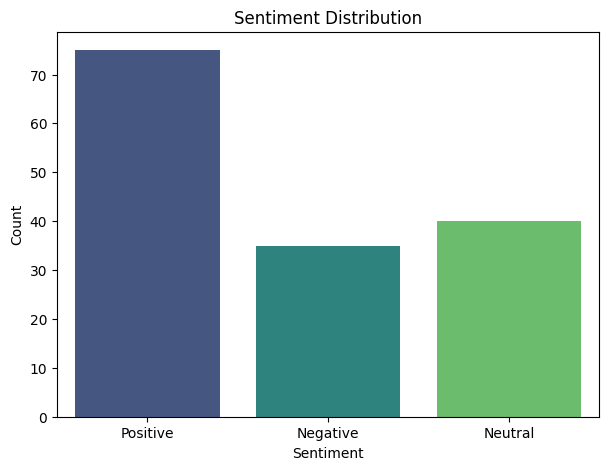

In [23]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Predicted_Sentiment",
    hue="Predicted_Sentiment",
    palette="viridis",
    legend=False
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.savefig(
    "figures/sentiment_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

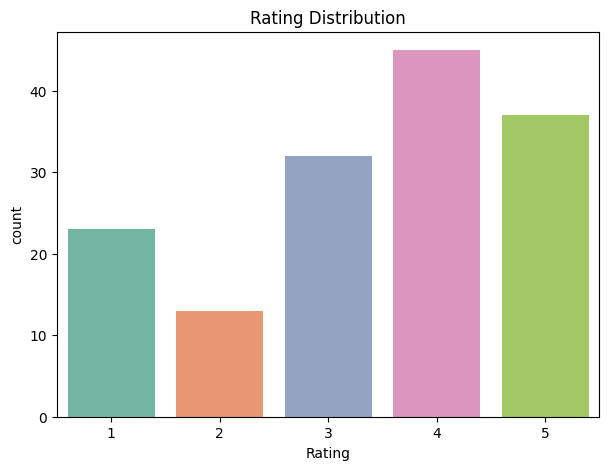

In [24]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Rating",
    hue="Rating",
    palette="Set2",
    legend=False
)

plt.title("Rating Distribution")

plt.savefig(
    "figures/rating_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

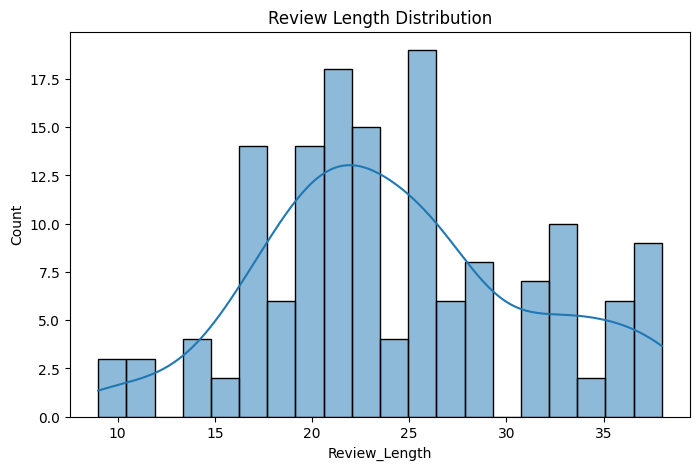

In [25]:
df["Review_Length"] = df["Cleaned_Review"].apply(len)

plt.figure(figsize=(8,5))

sns.histplot(
    df["Review_Length"],
    bins=20,
    kde=True
)

plt.title("Review Length Distribution")

plt.savefig(
    "figures/review_length_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

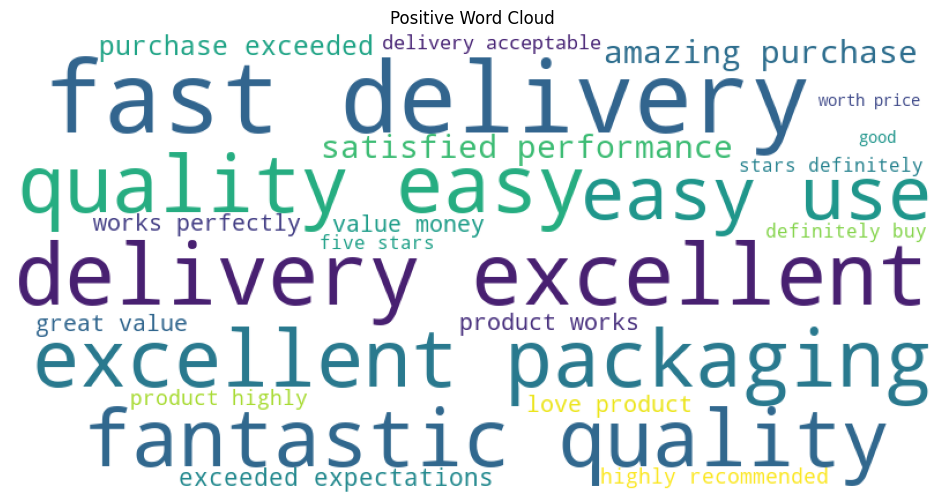

In [26]:
positive_reviews = " ".join(
    df[df["Predicted_Sentiment"]=="Positive"]["Cleaned_Review"]
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(positive_reviews)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Positive Word Cloud")

plt.savefig(
    "figures/wordcloud_positive.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

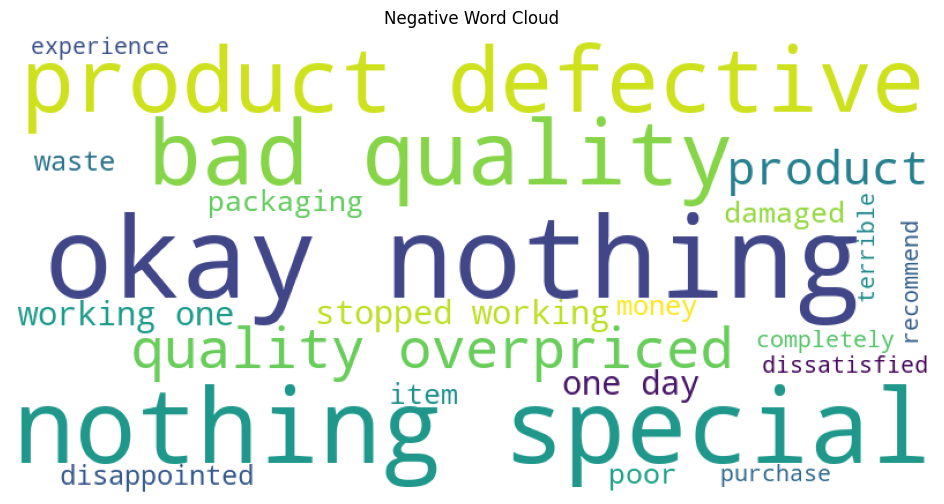

In [27]:
negative_reviews = " ".join(
    df[df["Predicted_Sentiment"]=="Negative"]["Cleaned_Review"]
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(negative_reviews)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Negative Word Cloud")

plt.savefig(
    "figures/wordcloud_negative.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [28]:
print("\nSummary Statistics\n")

print(df.describe())

print("\nSentiment Counts\n")

print(df["Predicted_Sentiment"].value_counts())


Summary Statistics

        Review_ID     Rating  Review_Length
count  150.000000  150.00000     150.000000
mean    75.500000    3.40000      24.380000
std     43.445368    1.35607       6.947232
min      1.000000    1.00000       9.000000
25%     38.250000    3.00000      20.000000
50%     75.500000    4.00000      23.000000
75%    112.750000    4.00000      28.000000
max    150.000000    5.00000      38.000000

Sentiment Counts

Predicted_Sentiment
Positive    75
Neutral     40
Negative    35
Name: count, dtype: int64


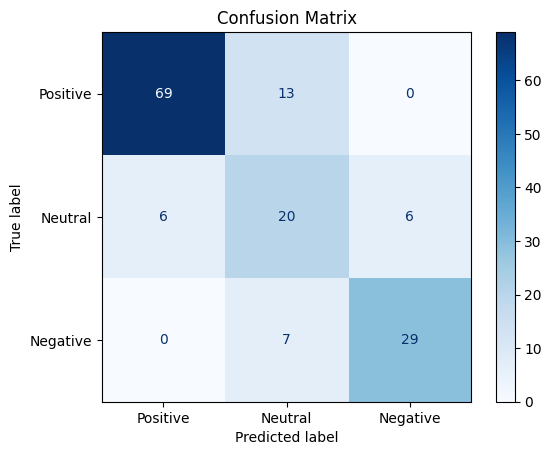

In [29]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(
    df["Expected_Sentiment"],
    df["Predicted_Sentiment"],
    labels=["Positive","Neutral","Negative"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Positive","Neutral","Negative"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.savefig(
    "figures/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [30]:
df.to_csv(
    "Amazon_Reviews_Sentiment.csv",
    index=False
)

In [31]:
df.head()

,Review_ID,Review_Text,Rating,Expected_Sentiment,Cleaned_Review,Predicted_Sentiment,Review_Length
0,1,Very satisfied with the performance.,4,Positive,satisfied performance,Positive,21
1,2,"It's okay, nothing special.",3,Neutral,okay nothing special,Negative,20
2,3,Great value for money.,4,Positive,great value money,Positive,17
3,4,The product stopped working after one day.,1,Negative,product stopped working one day,Negative,31
4,5,Fast delivery and excellent packaging.,5,Positive,fast delivery excellent packaging,Positive,33
